In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error


## Data Analysis

In [37]:
# ====================== Data Analysis =========================

data = pd.read_excel("data/OnlineRetail (1).xlsx")

print("First 5 Rows of Data: \n",data.head(10))

print("\nAll Columns of the data: ",data.columns)

print("\nChecking Data types stored in each column: ")
print(data.info())

print("\nChecking the Nan values from dataset: \n",data.isnull().sum(),"\n")

print("Checking for Duplicate Value: \n",data.duplicated().sum())


First 5 Rows of Data: 
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5    536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6    536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7    536366     22633               HAND WARMER UNION JACK         6   
8    536366     22632            HAND WARMER RED POLKA DOT         6   
9    536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United King

## Data Cleaning

In [38]:
# =================================== Data Cleaning =====================================

data = data.dropna()
print(data)

data = data.drop_duplicates()
print("After Deleting Duplicate Values: \n",data)

# Drop the data which Quantity are less than 0
data = data.drop(data[data["Quantity"] < 0].index,axis = 0)

# Drop the data which UnitPrice are less than and eqaul to 0
data = data.drop(data[data["UnitPrice"] <= 0].index,axis = 0)


       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  
0      

## Feature Encoding

In [39]:
# ====================== Feature Encoding =========================

# Converting Date (data type) column into DateTime (data type)
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"],format = "mixed")

data["Total_Price"] = data["Quantity"] * data["UnitPrice"]
print("After Making and Adding Total Price Column: \n",data)

print("\nTotal Revenue: \t",data["Total_Price"].sum())

print("\nTotal Orders: \n",data["InvoiceNo"].nunique())

print("\nTotal Customers: \n",data["CustomerID"].nunique())


After Making and Adding Total Price Column: 
        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  U

## Data Insights

In [40]:
# ====================== Data Insights =========================

print("\nSum of Top Selling Products: \n",(data.groupby("Description")["Quantity"].sum()).sort_values(ascending = False))

print("\nSum of Top Revenue Products: \n",data.groupby("Description")["Total_Price"].sum().sort_values(ascending = False))

print("\nThe Country which gave High Sales in Business: \n",(data.groupby("Country")["Quantity"].sum()).idxmax())

month_sal = data.groupby(data["InvoiceDate"].dt.month)["Total_Price"].sum()
print("\nMonthly Sales Analysis: \n",month_sal)

top_cus = (data.groupby("CustomerID")["Total_Price"].sum()).sort_values(ascending = False).iloc[:10]
print("\nTop 10 Customer: \n",top_cus)



Sum of Top Selling Products: 
 Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS      54319
JUMBO BAG RED RETROSPOT                46078
WHITE HANGING HEART T-LIGHT HOLDER     36706
                                       ...  
RUBY GLASS CLUSTER EARRINGS                1
BLUE/NAT SHELL NECKLACE W PENDANT          1
BLUE/GREEN SHELL NECKLACE W PENDANT        1
 I LOVE LONDON MINI RUCKSACK               1
HEN HOUSE W CHICK IN NEST                  1
Name: Quantity, Length: 3877, dtype: int64

Sum of Top Revenue Products: 
 Description
PAPER CRAFT , LITTLE BIRDIE           168469.600
REGENCY CAKESTAND 3 TIER              142264.750
WHITE HANGING HEART T-LIGHT HOLDER    100392.100
JUMBO BAG RED RETROSPOT                85040.540
MEDIUM CERAMIC TOP STORAGE JAR         81416.730
                                         ...    
PURPLE FRANGIPANI HAIRCLIP                 0.850
VINTAGE BLUE TINSEL REEL       

## RFM (Recency,Frequency,Monetary)

In [41]:
# ====================== Caluted RFM for business =========================

print("Recency: ",data["InvoiceDate"].sort_values(ascending = False).iloc[0])

print("Frequency: ",data["Quantity"].max())

print("Monetary: ",data["Total_Price"].max())

# Using Groupby Function to Calculate RFM

print("RFM Best Customer Overall: \n",data.groupby("CustomerID")[["Total_Price","Quantity","InvoiceDate"]].max().idxmax())


Recency:  2011-12-09 12:50:00
Frequency:  80995
Monetary:  168469.6
RFM Best Customer Overall: 
 Total_Price    16446.0
Quantity       16446.0
InvoiceDate    12680.0
dtype: float64


## Analysis Between Monthly Sales and Total_Price

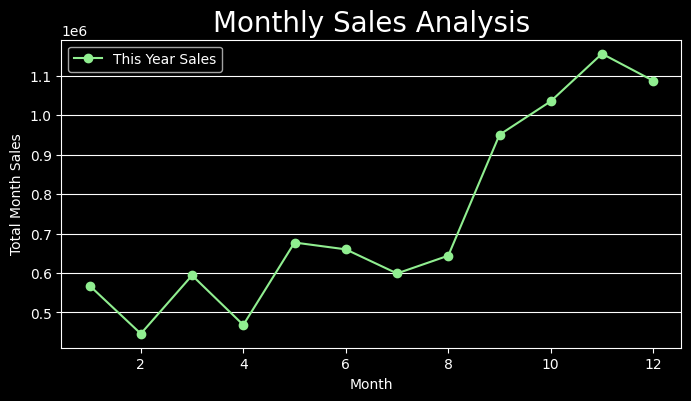

In [42]:
# ====================== Analysis Between Monthly Sales and Total_Price =========================

plt.style.use("dark_background")

plt.figure(figsize = (8,4))

plt.title("Monthly Sales Analysis",fontsize = 20)

plt.xlabel("Month")
plt.ylabel("Total Month Sales")

plt.plot(month_sal.index,month_sal,color = "lightgreen",label = "This Year Sales",marker = "o")

plt.grid(axis = "y")
plt.legend()
plt.show()

## Analysis of Top 10 High Revenue Products

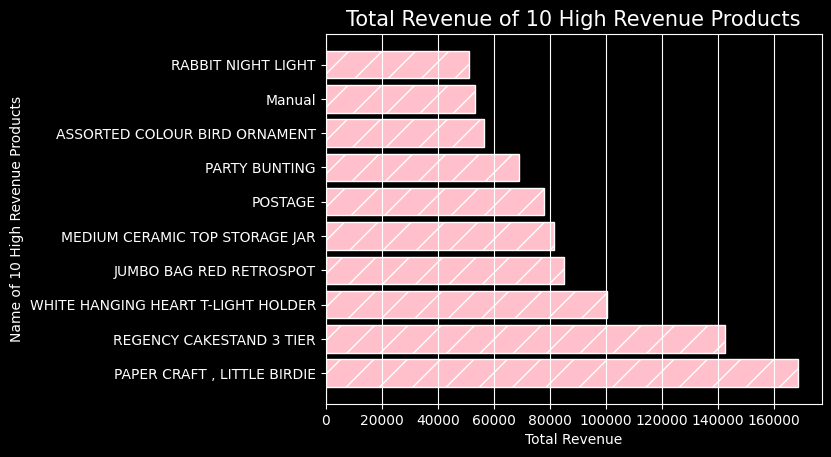

In [43]:
# ================================== Analysis of Top 10 High Revenue Products =========================================

plt.title("Total Revenue of 10 High Revenue Products",fontsize = 15)

x = data.groupby("Description")["Total_Price"].sum().sort_values(ascending = False).head(10)

plt.xlabel("Total Revenue")
plt.ylabel("Name of 10 High Revenue Products")

plt.barh(x.index,x,color = "pink",hatch = "/",edgecolor = "white")

plt.grid(axis = "x")
plt.show()


## Analysis of Top 10 High Sales Countries

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Total_Price, dtype: float64 



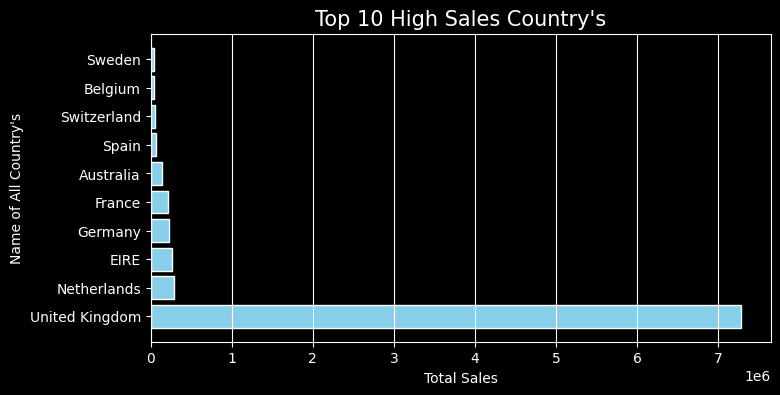

In [44]:
# ============================== Analysis of Top 10 High Sales Countries ===================================

plt.figure(figsize = (8,4))

plt.title("Top 10 High Sales Countries",fontsize = 15)

plt.xlabel("Total Sales")
plt.ylabel("Name of All Countries")

y = data.groupby("Country")["Total_Price"].sum().sort_values(ascending = False).head(10)
print(y,"\n")

plt.barh(y.index,y,color = "skyblue",edgecolor = "white")

plt.grid(axis = "x")
plt.show()

## Analysis of Top 10 Customers(Spending Rate)

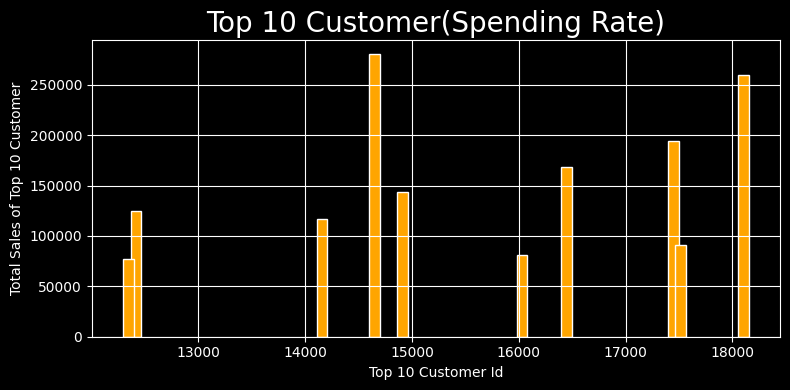

In [45]:
# ========================= Analysis of Top 10 Customers(Spending Rate)  =======================

plt.figure(figsize = (8,4))

plt.title("Top 10 Customer(Spending Rate)",fontsize = 20)

plt.xlabel("Top 10 Customer Id")
plt.ylabel("Total Sales of Top 10 Customer")

plt.bar(top_cus.index,top_cus,width = 100,color = "orange",edgecolor = "white")

plt.grid()
plt.tight_layout()
plt.show()


## Data Selection

In [46]:
# ====================== Data Selection =========================

model = LinearRegression()

X = data.loc[:,["Quantity","UnitPrice"]]

y = data["Total_Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1,random_state = 42)


## Prediction of Data By Machine Learning


R**2 Score of Prediced Data: 
 0.4899399332460509
Score is 0.4899399332460509 which is closer to 1
This Mean the predictted Value Accuracy By Machine is Much Better or You can say Veru Good Predition
MAD: 
 11.794737779122864
RMSE: 
 47.570869279063224


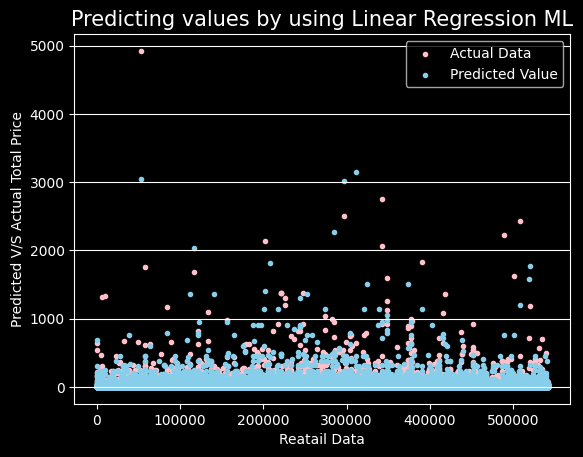

In [49]:
# =============================== Prediction of Data By Machine Learning =================================

model.fit(X_train,y_train)

pred = model.predict(X_test)

error = (y_test - pred)

r2 = r2_score(y_test,pred)
print("\nR**2 Score of Predicted Data: \n",r2)

print(f"Score is {r2} which is closer to 1\nThis Mean the predictted Value Accuracy By Machine is Much Better or You can say Very Good Predition")

MAE = mean_absolute_error(y_test,pred)
print("MAD: \n",MAE)

RMSE = root_mean_squared_error(y_test,pred)
print("RMSE: \n",RMSE)


plt.title("Predicting values by using Linear Regression ML",fontsize = 15)

plt.xlabel('Retail Data')
plt.ylabel("Predicted V/S Actual Total Price")

plt.scatter(y_test.index,y_test,color = "pink",label = "Actual Data",marker = ".")

plt.scatter(y_test.index,pred,color = "skyblue",label = "Predicted Value",marker = ".")

plt.grid(axis = "y")
plt.legend()
plt.show()
